# When Importance Sampling Fails: Rare-Event Estimation for Heavy-Tailed Insurance Losses
## A case study on the Danish Fire Insurance dataset

This project uses the Danish Fire Insurance dataset to study rare-event simulation for heavy-tailed insurance losses. After fitting a Pareto model to the claim severities, I estimate the probability of extreme aggregate annual losses via Monte Carlo and show that the naive estimator converges prohibitively slowly in the tail. This motivates importance sampling — but I demonstrate that a claim-level Pareto-tilting approach, while theoretically unbiased, fails in practice due to weight collapse, quantified by an effective sample size below 1%.

In [49]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.optimize import curve_fit

### Monte-Carlo simulation and fitting to a Pareto Model

/var/folders/hs/9tb20l2j17n8d_5zk178pnmr0000gn/T/ipykernel_4733/2174281071.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


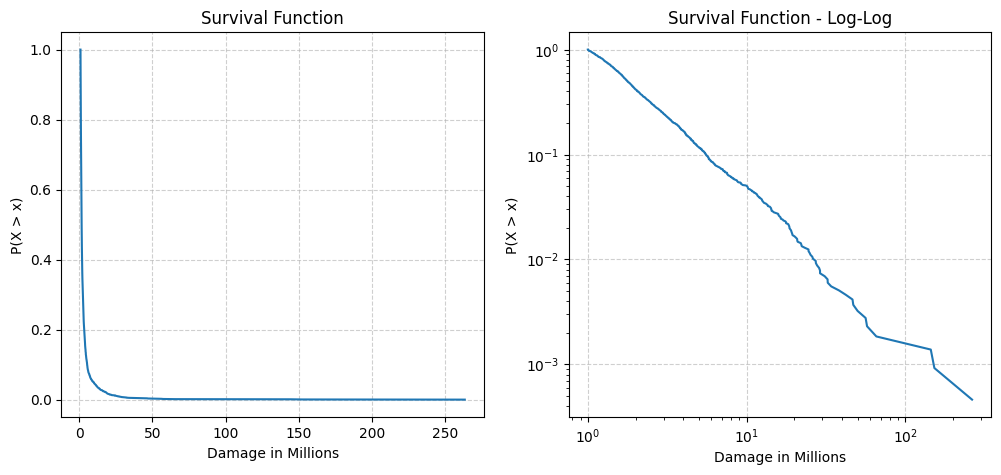

In [50]:
data = np.loadtxt(os.getcwd() + "/danish_fire_insurance.csv", delimiter = ",", skiprows = 1)    #Loading the Data
lossdata = data[:,1]

#PRE: Takes an array of claims
#POST: Returns the array of claims sorted from high to low and an array which gives the probability (at position i) of a claim higher than the i-th claim
def f_empirical_survival(data):
    sorted_data = np.sort(data)[::-1] # Sorts Data low -> high and then turns it around to high -> low
    n = len(sorted_data)
    empirical_survival = np.arange(1, n+1) / n

    return sorted_data, empirical_survival


sorted_data, empirical_survival = f_empirical_survival(lossdata)

fig = plt.figure(figsize = (12,5))
ax1, ax2 = fig.subplots(1,2)

#Plotting the Survival Function
ax1.plot(sorted_data, empirical_survival) 
ax1.set_title("Survival Function")
ax1.set_xlabel("Damage in Millions")
ax1.set_ylabel("P(X > x)")
ax1.grid(True, which='major', linestyle='--', alpha=0.6)


#Plotting the Survival Function in a LogLog plot
ax2.loglog(sorted_data, empirical_survival)
ax2.set_title("Survival Function - Log-Log")
ax2.set_xlabel("Damage in Millions")
ax2.set_ylabel("P(X > x)")
ax2.grid(True, which='major', linestyle='--', alpha=0.6)

fig.show()

The graph in the Log-Log plot resemles a linear function. Since the Pareto Survival Function is given by $$P(X > x) = (\frac{x_m}{x})^{\alpha}.$$ By taking the logarithm, we see $$log(P(X > x)) = \alpha (log(x_m) - log(x)) $$ which is a linear function. Now we want to know the value of $\alpha$.

Hill alpha = 1.362, Fitted alpha: 1.2047192043268913


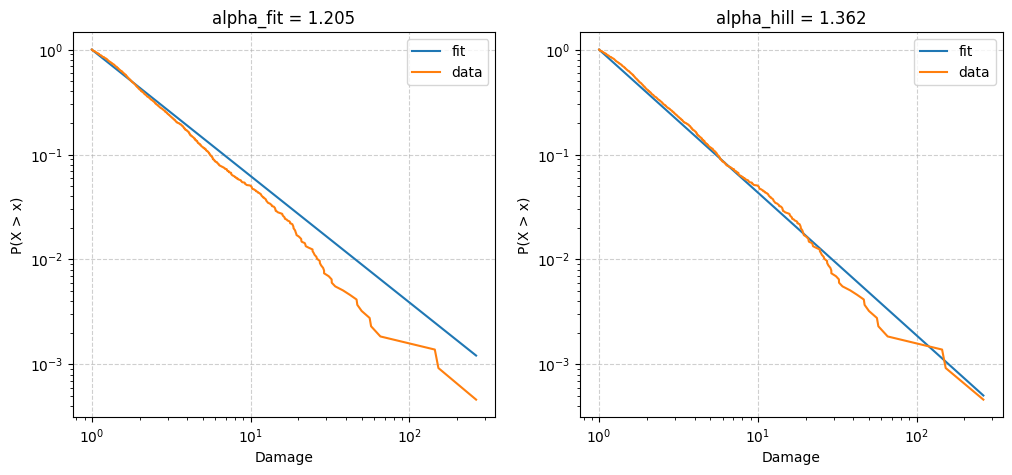

In [51]:
xmin = min(lossdata) # Gives us the value of x_m

#PRE: Takes an array like object x and a float alpha
#POST: returns the Pareto Survival Function of the object x
def pareto_function(x,alpha):
        return (xmin/x)**alpha


#Trying to find alpha by fitting the empirical values to the Pareto Survival Function
popt, pcov = curve_fit(pareto_function, sorted_data, empirical_survival) 
alpha_fit = popt[0] #Fitted alpha


#Trying to find alpha by the Hill Estimator
k = 200
sorted_asc = np.sort(lossdata)
alpha_hill = 1 / np.mean(np.log(sorted_asc[-k:] / sorted_asc[-k-1]))

#Comparing
print(f"Hill alpha = {alpha_hill:.3f}, Fitted alpha: {alpha_fit}")


fig2 = plt.figure(figsize = (12,5))
ax21, ax22 = fig2.subplots(1,2)

ax21.loglog(sorted_data, pareto_function(sorted_data, alpha_fit), label = "fit")
ax21.loglog(sorted_data, empirical_survival, label = "data")
ax21.set_title(f"alpha_fit = {np.round(alpha_fit,3)}")
ax21.set_xlabel("Damage")
ax21.set_ylabel("P(X > x)")
ax21.grid(True, which='major', linestyle='--', alpha=0.6)
ax21.legend()

ax22.loglog(sorted_data, pareto_function(sorted_data, alpha_hill), label = "fit")
ax22.loglog(sorted_data, empirical_survival, label = "data")
ax22.set_title(f"alpha_hill = {np.round(alpha_hill,3)}")
ax22.set_xlabel("Damage")
ax22.set_ylabel("P(X > x)")
ax22.grid(True, which='major', linestyle='--', alpha=0.6)
ax22.legend()


Gobal MLE underestimates the Tail systematically. Only the Hill Estimator - which exclusively uses extremal values - gives apropriate estimations for reinsurance-relavant Probabilities

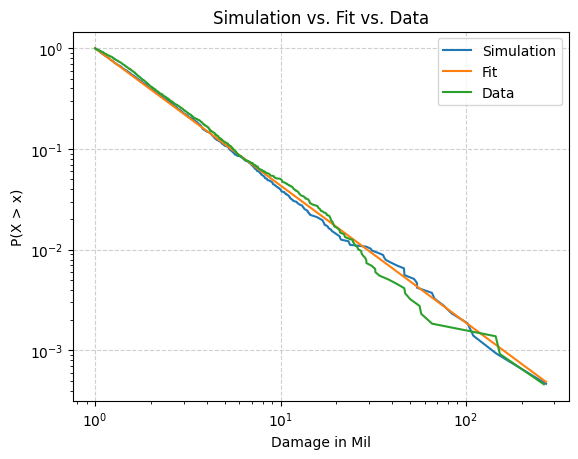

In [52]:
#PRE: Takes the minimal claim, the alpha, a number of events and a maximum claim.
#POST: Returns an array of pareto distributed claims
def pareto_distribution(min_claim, alpha, events, max_claim):
    vals = np.random.pareto(alpha, events)
    res = np.minimum(min_claim * (vals + 1), max_claim)
    return res
     

#PRE: Takes an int of expected_events, and an int of years
#POST: Returns an array of poisson distributed events per year
def poisson_distribution(expected_events, years):
    return np.random.poisson(expected_events, years)


#PRE: Takes an alpha, the timespan of the simulation in years, the expected events per year, the minimum and maximum claim
#POST: Returns an array of claims and an array of events per year
def naive_MC(alpha, years, expected_events, min_claim, max_claim):
    eventsperyear = poisson_distribution(expected_events, years)
    total_events = np.sum(eventsperyear)
    claims = pareto_distribution(min_claim, alpha, total_events, max_claim)
    return claims, eventsperyear


years = 11
expected_events = len(lossdata)/years
min_claim = 1
max_claim = np.inf


claims, cpy = naive_MC(alpha_hill, years, expected_events, min_claim, max_claim)




sorted_claims, empirical_survival_claims = f_empirical_survival(claims)

plt.loglog(sorted_claims, empirical_survival_claims, label = "Simulation")
plt.loglog(sorted_claims, pareto_function(sorted_claims, alpha_hill), label = "Fit")
plt.loglog(sorted_data, empirical_survival, label = "Data")
plt.title("Simulation vs. Fit vs. Data")
plt.xlabel("Damage in Mil")
plt.ylabel("P(X > x)")
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.legend()
plt.show()







### From individual claims to aggregate annual loss

The quantity a reinsurer actually cares about is the **aggregate annual loss**
$$S_N = \sum_{k=1}^{N} Y_k,$$
where the number of claims per year $N \sim \text{Poisson}(\lambda)$ and each claim severity $Y_k \sim \text{Pareto}(\alpha, x_m)$. We estimate the tail probability $P(S_N > x)$ by simulating many independent years.

P(S_N > 3000M) = 0.0055


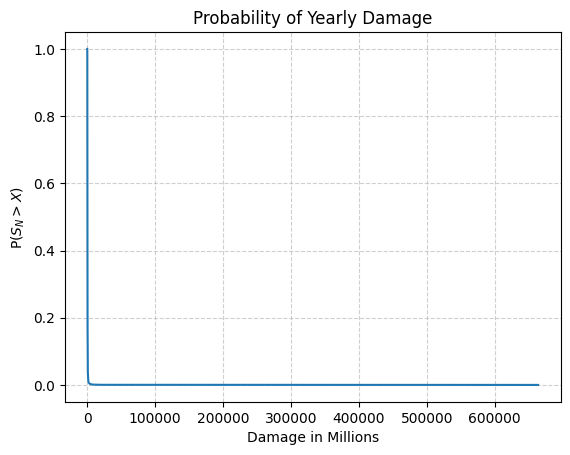

In [53]:
#PRE: Takes the number of simulations
#POST: returns an array of the aggregated yearly damages
def aggregated_yearly_damage(N_simulations):
    N_yearly_damages = np.array([np.sum(naive_MC(alpha_hill, 1, expected_events, min_claim, max_claim)[0]) for _ in range(N_simulations)])
    return N_yearly_damages


N_simulations = 100000
N_yearly_damages = aggregated_yearly_damage(N_simulations)

sorted_yearly_damages, empirical_yearly = f_empirical_survival(N_yearly_damages)

plt.plot(sorted_yearly_damages, empirical_yearly)
plt.title("Probability of Yearly Damage")
plt.xlabel("Damage in Millions")
plt.ylabel(r"P($S_N > X$)")
plt.grid(True, which='major', linestyle='--', alpha=0.6)


X = 3000
p_ruin = np.mean(N_yearly_damages > X)
print(f"P(S_N > {X}M) = {p_ruin:.4f}")






### Why naive Monte Carlo breaks down in the tail

The naive estimator $\hat{p} = \frac{1}{M}\sum_i \mathbf{1}[S_N^{(i)} > x]$ is unbiased, but its relative error scales like $1/\sqrt{Mp}$. For rare events ($p$ small) this requires an enormous number of simulations to converge.

The plots below show this directly: for a moderate threshold ($x = 600\text{M}$) the estimator stabilizes within a few thousand simulations, but for an extreme threshold ($x = 3000\text{M}$) the confidence interval remains wide even after 50,000 simulations. This is the practical limitation that motivates variance-reduction techniques such as importance sampling.

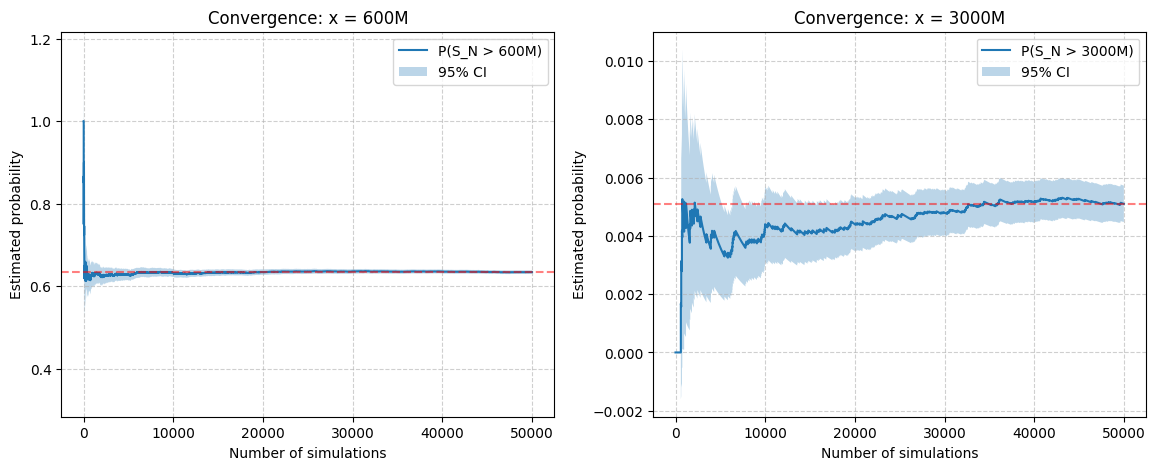

In [54]:
#PRE: Takes a threshold value and a number of maximum simulations
#POST: Returns an array of the running mean loss and an array of the running convergence interval
def convergence_analysis(x_threshold, N_max=50000):
    damages = aggregated_yearly_damage(N_max)
    
    running_mean = np.cumsum(damages > x_threshold) / np.arange(1, N_max + 1)
    
    n = np.arange(1, N_max + 1)
    ci = 1.96 * np.sqrt(running_mean * (1 - running_mean) / n)
    
    return running_mean, ci


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, x in zip([ax1, ax2], [600, 3000]):
    mean, ci = convergence_analysis(x, N_max=50000)
    n = np.arange(1, len(mean) + 1)
    
    ax.plot(n, mean, label=f'P(S_N > {x}M)')
    ax.fill_between(n, mean - ci, mean + ci, alpha=0.3, label='95% CI')
    ax.axhline(mean[-1], linestyle='--', color='red', alpha=0.5)
    ax.set_xlabel('Number of simulations')
    ax.set_ylabel('Estimated probability')
    ax.set_title(f'Convergence: x = {x}M')
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.legend()

### Importance sampling and weight collapse

Importance sampling reduces variance by drawing claims from a heavier-tailed proposal — here a tilted Pareto with $\alpha^* = 0.8\,\alpha$ — so that extreme events occur more frequently. Each sample is then reweighted by the likelihood ratio
$$W = \prod_{k=1}^{N} \frac{f_\alpha(Y_k)}{f_{\alpha^*}(Y_k)}$$
to keep the estimator unbiased.

In principle this should improve efficiency. In practice it fails: because each year contains ~200 claims, the product of ~200 likelihood ratios has extreme variance. A handful of simulations receive enormous weights while the rest contribute almost nothing — a phenomenon known as **weight collapse**.

We quantify this with the **effective sample size**
$$\text{ESS} = \frac{\left(\sum_i W_i\right)^2}{\sum_i W_i^2},$$
which measures how many simulations effectively contribute. As shown below, the ESS falls below 1% of $M$: the estimate is dominated by a few samples, making this estimator *less* reliable than naive Monte Carlo despite being theoretically superior.

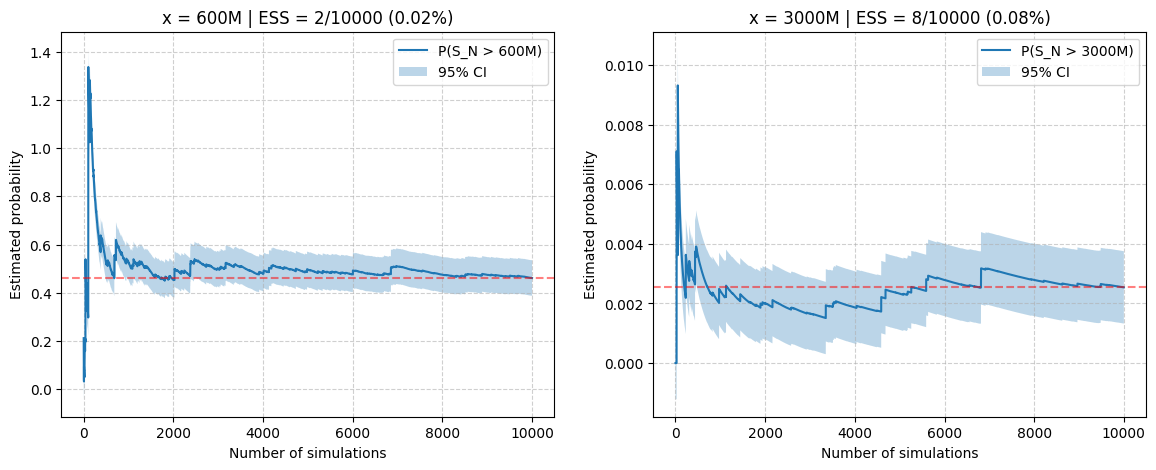

In [55]:
#PRE: Takes a value x and an alpha
#POST: returns a PDF value
def pareto_pdf(x,alpha):
    return sc.stats.pareto.pdf(x, alpha, scale = xmin)


#PRE: Takes a value x and two alphas of two different pareto PDFs
#POST: Returns the Likelihood between the first and the second PDF
def Likelihood(x, alpha1, alpha2):
    f1 = pareto_pdf(x, alpha1)
    f2 = pareto_pdf(x, alpha2)
    return f1/f2


def IS_estimator(alpha1, alpha2, M, x_threshold, years, expected_events, min_claim, max_claim):
    sums = np.zeros(M)
    weights = np.zeros(M)
    for i in range(M):
        eventsperyear = poisson_distribution(expected_events, years)
        total_events = np.sum(eventsperyear)
        claims = pareto_distribution(min_claim, alpha2, total_events, max_claim)
        sums[i] = np.sum(claims)
        weights[i] = np.exp(np.sum(np.log(Likelihood(claims, alpha1, alpha2))))
    
    Z = (sums > x_threshold) * weights
    var_Z = np.var(Z, ddof=1)
    ci = 1.96 * np.sqrt(var_Z / M)

    running_mean =  np.cumsum(Z) / np.arange(1, M + 1)
        
    return running_mean, ci, weights


#PRE: Takes the weights
#POST: returns the Effective sampling size
def effective_sample_size(weights):
    ESS = np.sum(weights)**2 / np.sum(weights**2)
    return ESS, ESS/len(weights)


alpha1 = alpha_hill
alpha2 = alpha_hill * 0.8
M = 10000






fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, x in zip([ax1, ax2], [600, 3000]):
    mean, ci, weights = IS_estimator(alpha1, alpha2, M, x, 1, expected_events, min_claim, max_claim)
    n = np.arange(1, len(mean) + 1)

    ESS, ESSM = effective_sample_size(weights)

    ax.plot(n, mean, label=f'P(S_N > {x}M)')
    ax.fill_between(n, mean - ci, mean + ci, alpha=0.3, label='95% CI')
    ax.axhline(mean[-1], linestyle='--', color='red', alpha=0.5)
    ax.set_xlabel('Number of simulations')
    ax.set_ylabel('Estimated probability')
    ax.set_title(f'x = {x}M | ESS = {ESS:.0f}/{M} ({ESSM:.2%})')
    ax.grid(True, which='major', linestyle='--', alpha=0.6)
    ax.legend()



This is a known limitation of naive importance sampling in high dimensions (the "curse of dimensionality"). Effective rare-event estimation for aggregate heavy-tailed losses typically requires methods that act on $S_N$ directly rather than on individual claims — for example exponential tilting on the aggregate, or Extreme Value Theory approaches based on the Generalized Pareto Distribution. This would be the natural next step.

### Goodness of fit

The QQ-plot compares empirical against theoretical Pareto quantiles. The fit is excellent through the bulk and mid-tail, where points lie on the diagonal. In the extreme tail the empirical quantiles fall slightly below the theoretical ones, suggesting the single Pareto model mildly overestimates the largest losses. However, this region rests on only a handful of observations, so the deviation is also consistent with sampling noise. A more refined analysis would model the tail separately using a Generalized Pareto Distribution.

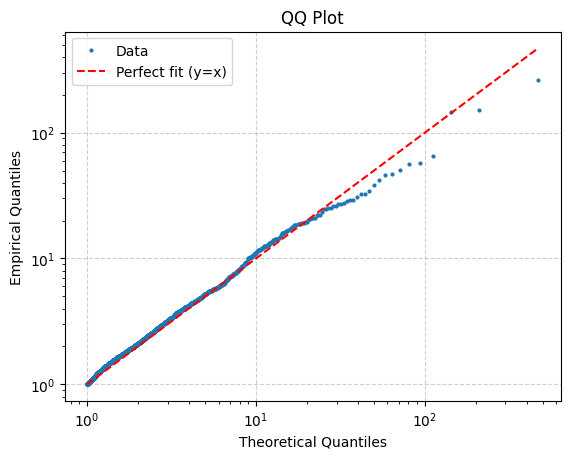

In [56]:
data_asc = np.sort(lossdata)  # aufsteigend
n = len(data_asc)
p = (np.arange(1, n+1) - 0.5) / n   # Plotting-Positionen
theoretical = sc.stats.pareto.ppf(p, alpha_hill, scale=xmin)

plt.loglog(theoretical, data_asc, 'o', markersize=2, label="Data")
plt.loglog(theoretical, theoretical, 'r--', label="Perfect fit (y=x)")
plt.grid(True, which='major', linestyle='--', alpha=0.6)
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Empirical Quantiles")
plt.title("QQ Plot")
plt.legend()